<a href="https://colab.research.google.com/github/cvilelahep/LIP_Internships26_SNDATLAS/blob/main/to_df.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
!pip install uproot
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import awkward as ak

In [3]:
# Get the data
from google.colab import drive
drive.mount('/content/drive')
! mkdir -p /drive/MyDrive/LIP_internships26_SNDATLAS/
! wget -N https://cristova.web.cern.ch/cristova/share/LIP_Internships/epos_lhc_14TeV_v2.root -P /drive/MyDrive/LIP_internships26_SNDATLAS/
! wget -N https://cristova.web.cern.ch/cristova/share/LIP_Internships/pwgevents-PYTHIA-filtered_v2.root -P /drive/MyDrive/LIP_internships26_SNDATLAS/

! ls /drive/MyDrive/LIP_internships26_SNDATLAS/

data_path = "/drive/MyDrive/LIP_internships26_SNDATLAS/"

Mounted at /content/drive
--2026-07-13 09:21:47--  https://cristova.web.cern.ch/cristova/share/LIP_Internships/epos_lhc_14TeV_v2.root
Resolving cristova.web.cern.ch (cristova.web.cern.ch)... 137.138.55.232, 188.184.96.45, 188.184.111.229, ...
Connecting to cristova.web.cern.ch (cristova.web.cern.ch)|137.138.55.232|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 218362057 (208M)
Saving to: ‘/drive/MyDrive/LIP_internships26_SNDATLAS/epos_lhc_14TeV_v2.root’

epos_lhc_14TeV_v2.r 100%[===================>] 208.25M  23.6MB/s    in 10s     

2026-07-13 09:21:58 (20.2 MB/s) - ‘/drive/MyDrive/LIP_internships26_SNDATLAS/epos_lhc_14TeV_v2.root’ saved [218362057/218362057]

--2026-07-13 09:21:59--  https://cristova.web.cern.ch/cristova/share/LIP_Internships/pwgevents-PYTHIA-filtered_v2.root
Resolving cristova.web.cern.ch (cristova.web.cern.ch)... 137.138.55.232, 188.184.96.45, 188.184.111.229, ...
Connecting to cristova.web.cern.ch (cristova.web.cern.ch)|137.138.55.232|:4

In [6]:
signal = uproot.open(data_path+"/pwgevents-PYTHIA-filtered_v2.root:Events")
background = uproot.open(data_path+"/epos_lhc_14TeV_v2.root:Events")
signal.show()


name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
npdg                 | int32_t                  | AsDtype('>i4')
pdg                  | int64_t[]                | AsJagged(AsDtype('>i8'))
ncharge              | int32_t                  | AsDtype('>i4')
charge               | double[]                 | AsJagged(AsDtype('>f8'))
npx                  | int32_t                  | AsDtype('>i4')
px                   | double[]                 | AsJagged(AsDtype('>f8'))
npy                  | int32_t                  | AsDtype('>i4')
py                   | double[]                 | AsJagged(AsDtype('>f8'))
npz                  | int32_t                  | AsDtype('>i4')
pz                   | double[]                 | AsJagged(AsDtype('>f8'))
neta                 | int32_t                  | AsDtype('>i4')
eta                  | double[]                 | AsJagged(AsDtype('>f8')

In [4]:
def makeDataFrame(root_tree):
  this_df = pd.DataFrame()
  this_df["n"] = 0.0

  n = 0
  for i_event, event in enumerate(root_tree["npt"].array()):
    if i_event % 10000 == 0:
      print(f"Processing event {i_event}")
    this_df._set_value(index=n, col="n", value = event)
    n+=1

  for key in root_tree.keys():
    print(f"Processing {key}")
    if key.startswith("n") or key.startswith("m") or key.startswith("charge") or key.startswith("pdg"): continue

    for i in range(1, 4):
      this_df[key + str(i)] = 0.0
    n = 0
    for event in root_tree[key].array():
      for j in range(0, min(3,len(event))):
        this_df._set_value(index=n, col=key + str(j+1), value = event[j])
      n += 1
  #this_df._set_value(index=n, col=key + str(i), value = event[j])

  #this_df["mpt"] = root_tree["mpt"].array()
  this_df["nu_eta"] = root_tree["nu_eta"].array()
  this_df["nu_phi"] = root_tree["nu_phi"].array()
  this_df["nu_E"] = root_tree["nu_E"].array()


  this_df["dphi2"] = this_df["phi2"] - this_df["phi1"]
  this_df["dphi3"] = this_df["phi3"] - this_df["phi1"]
  this_df["p1"] = np.sqrt(this_df["px1"]**2 + this_df["py1"]**2 + this_df["pz1"]**2)
  this_df["p2"] = np.sqrt(this_df["px2"]**2 + this_df["py2"]**2 + this_df["pz2"]**2)
  this_df["p3"] = np.sqrt(this_df["px3"]**2 + this_df["py3"]**2 + this_df["pz3"]**2)
  this_df["nu_dphi1"] = this_df["phi1"] - this_df["nu_phi"]
  this_df["nu_dphi2"] = this_df["phi2"] - this_df["nu_phi"]
  this_df["nu_dphi3"] = this_df["phi3"] - this_df["nu_phi"]


  this_df = this_df.fillna(0)
  this_df.head()
  return this_df

In [7]:
background_df = makeDataFrame(signal)
signal_df = makeDataFrame(background)

Processing event 0
Processing event 1000
Processing event 2000
Processing event 3000
Processing event 4000
Processing event 5000
Processing event 6000
Processing event 7000
Processing event 8000
Processing event 9000
Processing event 10000
Processing event 11000
Processing event 12000
Processing event 13000
Processing event 14000
Processing event 15000
Processing event 16000
Processing event 17000
Processing event 18000
Processing event 19000
Processing event 20000
Processing event 21000
Processing event 22000
Processing event 23000
Processing event 24000
Processing event 25000
Processing event 26000
Processing event 27000
Processing event 28000
Processing event 29000
Processing event 30000
Processing event 31000
Processing event 32000
Processing event 33000
Processing event 34000
Processing event 35000
Processing event 36000
Processing event 37000
Processing event 38000
Processing event 39000
Processing event 40000
Processing event 41000
Processing event 42000
Processing event 43000
P

In [9]:
signal_df.tail()
background_df.tail()

,n,px1,px2,px3,py1,py2,py3,pz1,pz2,pz3,...,nu_phi,nu_E,dphi2,dphi3,p1,p2,p3,nu_dphi1,nu_dphi2,nu_dphi3
50879,47.0,-0.695763,-0.775099,0.672252,0.871712,0.646611,0.652363,-6.788004,-0.443236,17.687986,...,0.491709,39.767532,0.201913,-1.474028,6.879023,1.102426,17.712774,1.752704,1.954616,0.278676
50880,144.0,-0.031147,0.855852,-0.271777,-1.419306,-1.070166,1.156803,2.135103,0.504450,3.764332,...,-1.251365,420.123670,0.696523,3.394288,2.563993,1.460208,3.947436,-0.341374,0.355149,3.052914
50881,44.0,-1.149998,0.940758,0.707451,-0.509208,-0.556397,-0.803454,33.574087,7.078216,2.702671,...,2.639435,286.494025,2.190653,1.875897,33.597636,7.162104,2.906967,-5.364185,-3.173532,-3.488288
50882,70.0,-0.019004,-0.620973,-0.629583,-1.274193,1.083555,0.862627,-28.461260,-1.482770,3.585837,...,-2.771615,387.258790,3.676902,3.786982,28.489774,1.938634,3.741487,1.185906,4.862808,4.972888
50883,156.0,-2.014637,1.981646,1.392364,0.005895,-0.020648,-0.501691,-0.165124,-46.568650,-6.093445,...,0.556394,815.686208,-3.149085,-3.484502,2.021401,46.610798,6.270602,2.582272,-0.566813,-0.902230


In [10]:
import numpy as np

def apply_pt_eta_cuts(df, pt_min=0.250, eta_max=4, n_particles=3):
    """
    Zeroes out (px, py, pz) for particles failing pt or eta cuts.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns px{i}, py{i}, pz{i} for i in 1..n_particles.
        Momenta assumed to be in GeV.
    pt_min : float
        Minimum transverse momentum in GeV (default 0.250 GeV = 250 MeV).
    eta_max : float
        Maximum |eta| allowed (default 4).
    n_particles : int
        Number of particles per row (default 3).

    Returns
    -------
    pd.DataFrame
        A copy of df with px/py/pz set to 0 for particles failing either cut.
    """
    df = df.copy()

    for i in range(1, n_particles + 1):
        px, py, pz = f'px{i}', f'py{i}', f'pz{i}'

        # --- Transverse momentum cut ---
        pt = np.sqrt(df[px]**2 + df[py]**2)
        low_pt_mask = pt < pt_min
        df.loc[low_pt_mask, [px, py, pz]] = 0

        # --- Recompute pt after zeroing, then eta cut ---
        pt = np.sqrt(df[px]**2 + df[py]**2)
        with np.errstate(divide='ignore', invalid='ignore'):
            eta = np.arcsinh(df[pz] / pt)
        eta = eta.fillna(np.inf)  # pt=0 particles fail the eta cut too

        high_eta_mask = eta.abs() >= eta_max
        df.loc[high_eta_mask, [px, py, pz]] = 0

    return df

In [11]:
signal_df = apply_pt_eta_cuts(signal_df)
background_df = apply_pt_eta_cuts(background_df)

In [12]:
signal_df["target"] = 1.
background_df["target"] = 0.
signal_df = signal_df.drop(columns=["phi1", "phi2", "phi3"])
background_df = background_df.drop(columns=["phi1", "phi2", "phi3"])


In [14]:
signal_df.to_csv("signal_v2_eta_E.csv", index=False)
background_df.to_csv("background_v2_eta_E.csv", index=False)

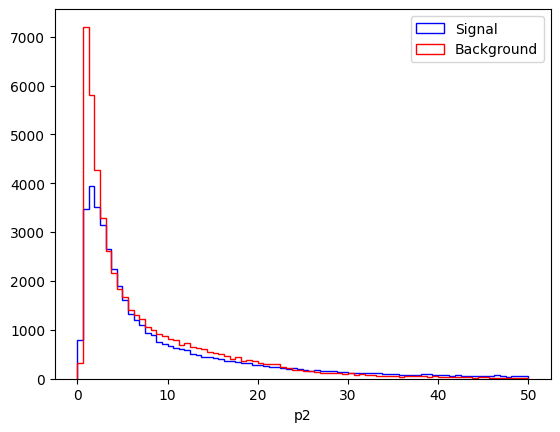

In [15]:

plt.figure()

plt.hist(
    signal_df["p2"][signal_df["p2"] != 0].dropna(),
    bins=80,
    range=(0, 50),
    histtype="step",
    linewidth=1,
    color="b",
    label="Signal"
)

plt.hist(
    background_df["p2"][background_df["p2"] != 0].dropna(),
    bins=80,
    range=(0, 50),
    histtype="step",
    linewidth=1,
    color="r",
    label="Background"
)

plt.xlabel("p2")
plt.legend()
plt.show()